# PGA Tour Hot Hand Study — Part 2: Analysis

**Question:** Does performing well on one hole make you more likely to perform well on the next — or is each hole essentially independent?

This is the "hot hand" question. In basketball, decades of research argued it was a cognitive illusion (Gilovich et al., 1985). More recent work has found small but real hot hand effects in various sports. Golf is a particularly clean test case: no defense, standardized scoring, and 18 independent scoring units per round.

Arkes (2016) used PGA ShotLink data (2003–2013) and found **no hot hand**, but a **significant cold hand** — players who struggled on a set of holes tended to continue struggling. This analysis replicates that framework on 2020–2024 ESPN data.

---

**What we test:**
1. Do transition probabilities show streakiness? (descriptive)
2. Does a good previous hole predict a better current hole? (regression)
3. Is the effect symmetric — same for good *and* bad runs? (Arkes split)
4. Which players are most "streaky"? (individual rankings)
5. Does player streakiness correlate with performance? (prediction)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
import os

warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

# Visual style — clean, no gridlines by default, readable fonts
plt.rcParams.update({
    "figure.dpi":        120,
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "font.family":       "sans-serif",
})

COLORS = {
    "eagle":   "#1a6b3c",
    "birdie":  "#4aab6d",
    "par":     "#aaaaaa",
    "bogey":   "#e07b39",
    "double":  "#c0392b",
    "blue":    "#2c7bb6",
    "neutral": "#888888",
}

print("Libraries loaded.")

Libraries loaded.


In [4]:
holes_df = pd.read_parquet("/content/drive/MyDrive/holes_2020_2024.parquet")
leaderboards = pd.read_parquet("/content/drive/MyDrive/leaderboards_2020_2024.parquet")
schedule = pd.read_parquet("/content/drive/MyDrive/schedule_2020_2024.parquet")

print(f"Hole data:    {len(holes_df):,} rows")
print(f"Leaderboards: {len(leaderboards):,} rows")
print()
print(holes_df.dtypes)
print()
print(holes_df.head(3))

Hole data:    138,229 rows
Leaderboards: 29,377 rows

player_id           object
player_name         object
round                int64
hole                 int64
par                  int64
score              float64
score_to_par       float64
score_type          object
tournament_id       object
tournament_name     object
year                 int64
dtype: object

  player_id player_name  round  hole  par  score  score_to_par score_type  \
0       388  Adam Scott      1    10    4    3.0          -1.0     BIRDIE   
1       388  Adam Scott      1    11    5    5.0           0.0        PAR   
2       388  Adam Scott      1    12    4    5.0           1.0      BOGEY   

  tournament_id           tournament_name  year  
0     401155423  The Genesis Invitational  2020  
1     401155423  The Genesis Invitational  2020  
2     401155423  The Genesis Invitational  2020  


## 1. Feature Engineering

Before running any regressions, we need to set up the data properly.

**Key decisions:**
- Sort by player → tournament → round → hole so lag-1 is the true previous hole
- Only keep consecutive holes (`hole == prev_hole + 1`) to avoid cross-round contamination
- Create a "hole difficulty control" — the average score on that hole across all players that round — to separate player momentum from course conditions
- Split the lag score into two variables (below par, above par) following Arkes (2016). This is the crucial step that separates hot hand from cold hand instead of blending them into one coefficient.


In [5]:

holes_df = holes_df.sort_values(
    ["player_id", "tournament_id", "round", "hole"]
).reset_index(drop=True)

g = holes_df.groupby(["player_id", "tournament_id", "round"])
holes_df["prev_score_to_par"] = g["score_to_par"].shift(1)
holes_df["prev_hole"]         = g["hole"].shift(1)

holes_df = holes_df[holes_df["hole"] == holes_df["prev_hole"] + 1].copy()

print(f"Consecutive-hole pairs: {len(holes_df):,}")
print(f"Unique players: {holes_df['player_id'].nunique()}")
print(f"Unique tournaments: {holes_df['tournament_id'].nunique()}")

Consecutive-hole pairs: 130,499
Unique players: 246
Unique tournaments: 64


In [6]:

hole_avg = (
    holes_df
    .groupby(["tournament_id", "round", "hole"])["score_to_par"]
    .mean()
    .reset_index()
    .rename(columns={"score_to_par": "hole_avg"})
)
holes_df = holes_df.merge(hole_avg, on=["tournament_id", "round", "hole"], how="left")

player_avg = (
    holes_df
    .groupby("player_id")["score_to_par"]
    .mean()
    .reset_index()
    .rename(columns={"score_to_par": "player_avg"})
)
holes_df = holes_df.merge(player_avg, on="player_id", how="left")

holes_df["below_par_prev"] = (-holes_df["prev_score_to_par"]).clip(lower=0)
holes_df["above_par_prev"] = ( holes_df["prev_score_to_par"]).clip(lower=0)

def score_category(s):
    if s <= -2: return "Eagle+"
    elif s == -1: return "Birdie"
    elif s == 0:  return "Par"
    elif s == 1:  return "Bogey"
    else:         return "Double+"

holes_df["score_cat"]      = holes_df["score_to_par"].apply(score_category)
holes_df["prev_score_cat"] = holes_df["prev_score_to_par"].apply(score_category)

CAT_ORDER = ["Eagle+", "Birdie", "Par", "Bogey", "Double+"]
holes_df["score_cat"]      = pd.Categorical(holes_df["score_cat"],      categories=CAT_ORDER, ordered=True)
holes_df["prev_score_cat"] = pd.Categorical(holes_df["prev_score_cat"], categories=CAT_ORDER, ordered=True)

print(f"Feature engineering complete. Final dataset: {len(holes_df):,} rows")
print()
print(holes_df[["score_to_par", "prev_score_to_par", "below_par_prev",
                "above_par_prev", "hole_avg", "player_avg"]].describe().round(3))

Feature engineering complete. Final dataset: 130,499 rows

       score_to_par  prev_score_to_par  below_par_prev  above_par_prev  \
count    130499.000         130499.000      130499.000      130499.000   
mean         -0.085             -0.091           0.242           0.151   
std           0.653              0.652           0.443           0.395   
min          -3.000             -3.000           0.000           0.000   
25%           0.000              0.000          -0.000           0.000   
50%           0.000              0.000           0.000           0.000   
75%           0.000              0.000          -0.000           0.000   
max           5.000              5.000           3.000           5.000   

         hole_avg  player_avg  
count  130499.000  130499.000  
mean       -0.085      -0.085  
std         0.256       0.032  
min        -1.067      -0.221  
25%        -0.233      -0.104  
50%        -0.067      -0.088  
75%         0.067      -0.071  
max         0.733 

## 2. Score Landscape

Before testing for the hot hand, let's understand what the score distribution looks like. What percentage of holes are birdies? How has birdie rate changed over the years? This sets the baseline for everything that follows.

,year,birdie_rate,bogey_rate
0,2020,0.232255,0.140294
1,2021,0.233532,0.145079
2,2022,0.226061,0.147885
3,2023,0.231958,0.140261
4,2024,0.241403,0.132541


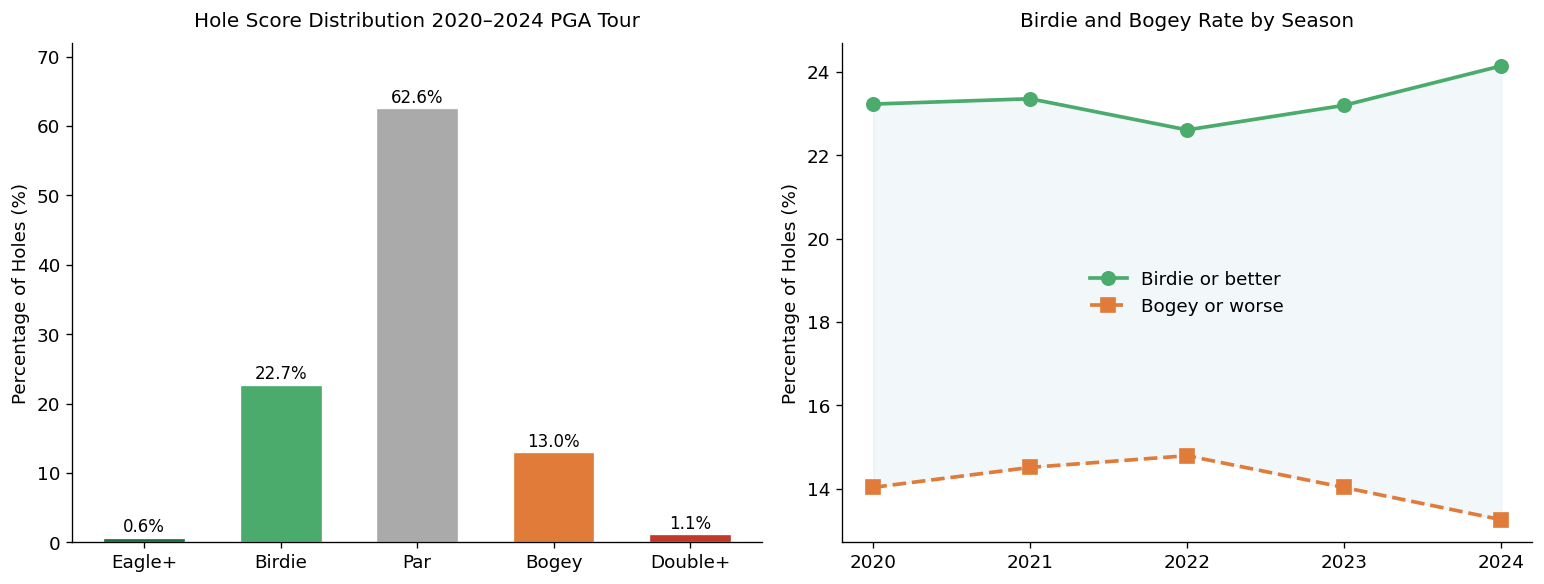

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

score_counts = holes_df["score_cat"].value_counts().reindex(CAT_ORDER)
total = score_counts.sum()
pcts  = score_counts / total * 100

bar_colors = [COLORS["eagle"], COLORS["birdie"], COLORS["par"],
              COLORS["bogey"], COLORS["double"]]

bars = axes[0].bar(CAT_ORDER, pcts, color=bar_colors, width=0.6, edgecolor="white", linewidth=0.8)
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

axes[0].set_title("Hole Score Distribution 2020–2024 PGA Tour", fontsize=12, pad=10)
axes[0].set_ylabel("Percentage of Holes (%)")
axes[0].set_ylim(0, pcts.max() * 1.15)

year_rates = (
    holes_df
    .assign(birdie=holes_df["score_to_par"] < 0,
            bogey=holes_df["score_to_par"] > 0)
    .groupby("year")
    .agg(birdie_rate=("birdie", "mean"), bogey_rate=("bogey", "mean"))
    .reset_index()
)

axes[1].plot(year_rates["year"], year_rates["birdie_rate"] * 100,
             "o-", color=COLORS["birdie"], lw=2.2, ms=8, label="Birdie or better")
axes[1].plot(year_rates["year"], year_rates["bogey_rate"] * 100,
             "s--", color=COLORS["bogey"], lw=2.2, ms=8, label="Bogey or worse")

axes[1].fill_between(year_rates["year"],
                     year_rates["birdie_rate"] * 100,
                     year_rates["bogey_rate"] * 100,
                     alpha=0.06, color=COLORS["blue"])

axes[1].set_title("Birdie and Bogey Rate by Season", fontsize=12, pad=10)
axes[1].set_ylabel("Percentage of Holes (%)")
axes[1].set_xticks(sorted(year_rates["year"].unique()))
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/01_score_landscape.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Transition Matrix

The most direct way to look for streakiness: what happens on the hole *after* an eagle, birdie, par, bogey, or double?

If golf is truly random (no hot hand, no cold hand), each row of the matrix below should look roughly the same — the previous score shouldn't change the distribution of the next score.

If we see elevated probabilities along the diagonal, that's a streakiness signal.

In [12]:

transition = pd.crosstab(
    holes_df["prev_score_cat"],
    holes_df["score_cat"],
    normalize="index"
) * 100

print("Transition matrix (row = previous hole, values = % of next holes):")
print(transition.round(1).to_string())
print()

baseline = holes_df["score_cat"].value_counts(normalize=True).reindex(CAT_ORDER) * 100
print("Overall baseline rates (%):")
print(baseline.round(2).to_string())

Transition matrix (row = previous hole, values = % of next holes):
score_cat       Eagle+  Birdie   Par  Bogey  Double+
prev_score_cat                                      
Eagle+             0.1    17.8  65.9   14.6      1.6
Birdie             0.5    21.1  64.2   13.0      1.2
Par                0.6    23.1  62.3   12.8      1.1
Bogey              0.7    23.8  60.6   13.5      1.3
Double+            0.3    24.3  59.9   14.3      1.2

Overall baseline rates (%):
score_cat
Eagle+      0.61
Birdie     22.70
Par        62.55
Bogey      12.99
Double+     1.15


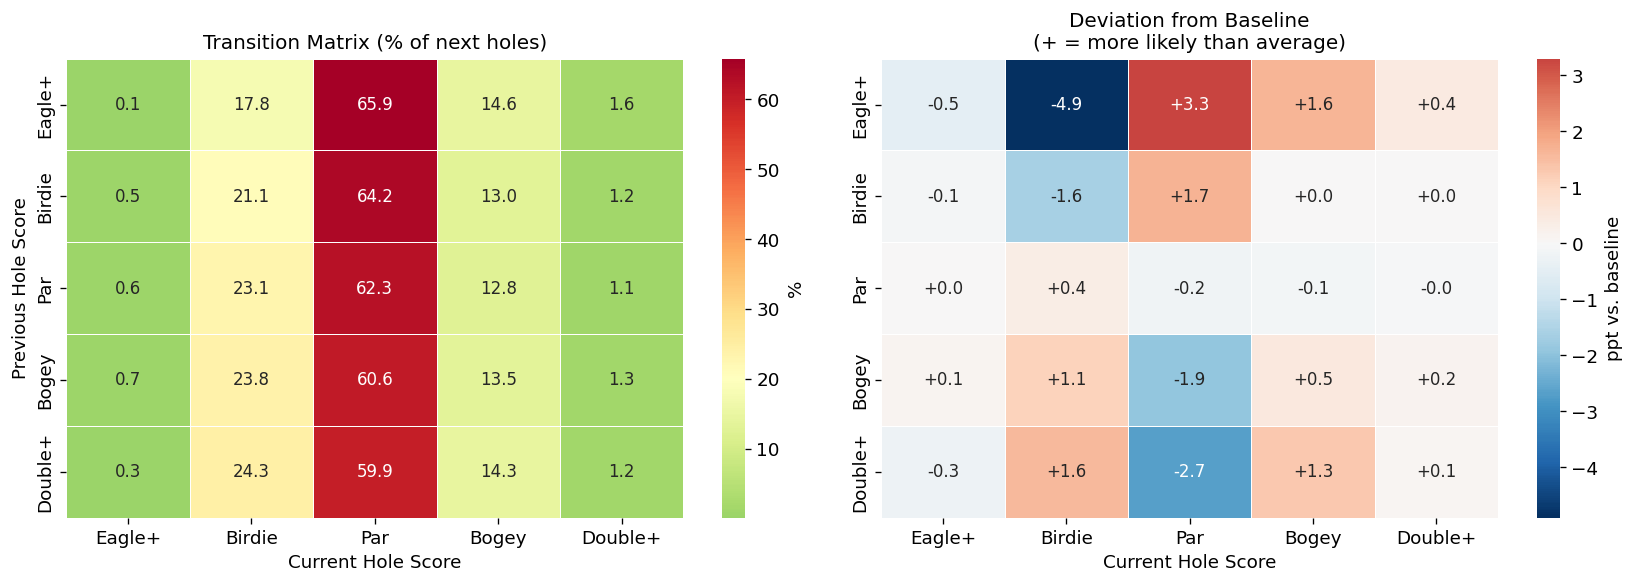


Diagonal cells (streakiness signal) — deviation from baseline:
  After   Eagle+: -0.49 ppt
  After   Birdie: -1.60 ppt
  After      Par: -0.21 ppt
  After    Bogey: +0.49 ppt
  After  Double+: +0.09 ppt


In [14]:

deviation = transition.copy()
for col in CAT_ORDER:
    deviation[col] = transition[col] - baseline[col]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    transition, ax=axes[0], annot=True, fmt=".1f",
    cmap="RdYlGn_r", center=baseline.mean(),
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "%"},
    annot_kws={"size": 10}
)
axes[0].set_title("Transition Matrix (% of next holes)", fontsize=12)
axes[0].set_xlabel("Current Hole Score")
axes[0].set_ylabel("Previous Hole Score")

sns.heatmap(
    deviation, ax=axes[1], annot=True, fmt="+.1f",
    cmap="RdBu_r", center=0,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "ppt vs. baseline"},
    annot_kws={"size": 10}
)
axes[1].set_title("Deviation from Baseline\n(+ = more likely than average)", fontsize=12)
axes[1].set_xlabel("Current Hole Score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("figures/02_transition_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDiagonal cells (streakiness signal) — deviation from baseline:")
for cat in CAT_ORDER:
    print(f"  After {cat:>8s}: {deviation.loc[cat, cat]:+.2f} ppt")

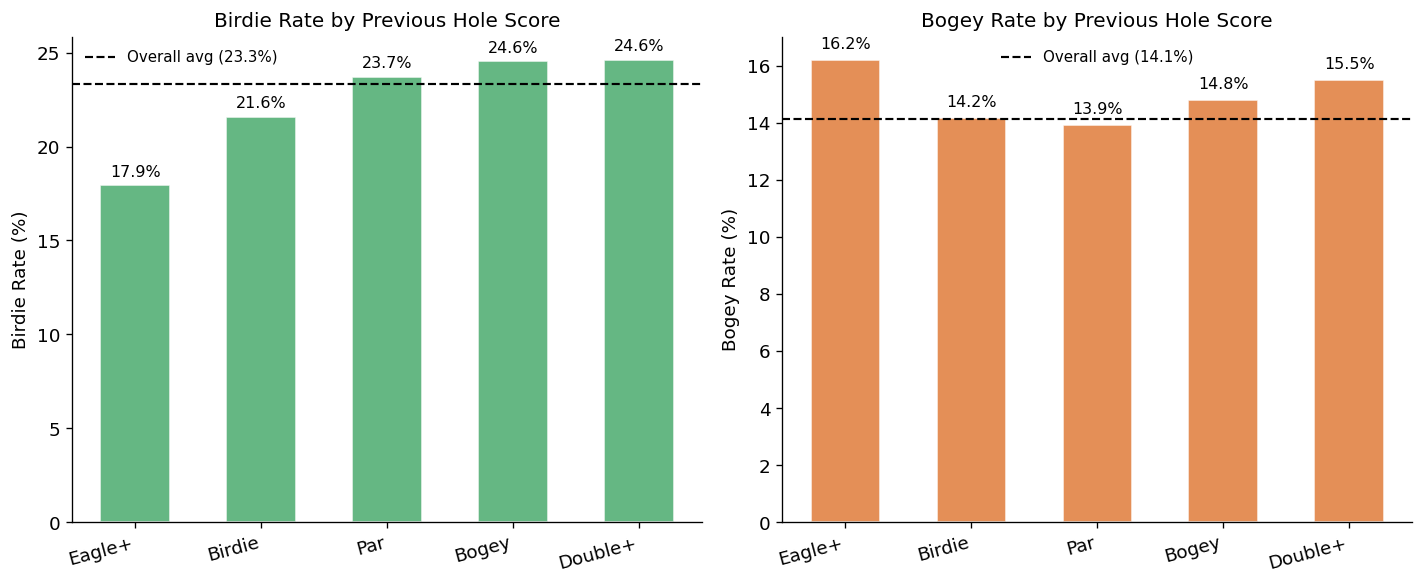

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

birdie_rate = []
bogey_rate  = []
avg_score   = []
n_obs       = []

for cat in CAT_ORDER:
    subset = holes_df[holes_df["prev_score_cat"] == cat]
    birdie_rate.append((subset["score_to_par"] < 0).mean() * 100)
    bogey_rate.append( (subset["score_to_par"] > 0).mean() * 100)
    avg_score.append(  subset["score_to_par"].mean())
    n_obs.append(len(subset))

overall_birdie = (holes_df["score_to_par"] < 0).mean() * 100
overall_bogey  = (holes_df["score_to_par"] > 0).mean() * 100

x = range(len(CAT_ORDER))

axes[0].bar(x, birdie_rate, color=[COLORS["birdie"]] * 5, alpha=0.85,
            width=0.55, edgecolor="white")
axes[0].axhline(overall_birdie, color="black", ls="--", lw=1.3,
                label=f"Overall avg ({overall_birdie:.1f}%)")
for i, (v, n) in enumerate(zip(birdie_rate, n_obs)):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=9.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CAT_ORDER, rotation=15, ha="right")
axes[0].set_title("Birdie Rate by Previous Hole Score", fontsize=12)
axes[0].set_ylabel("Birdie Rate (%)")
axes[0].legend(frameon=False, fontsize=9)

axes[1].bar(x, bogey_rate, color=[COLORS["bogey"]] * 5, alpha=0.85,
            width=0.55, edgecolor="white")
axes[1].axhline(overall_bogey, color="black", ls="--", lw=1.3,
                label=f"Overall avg ({overall_bogey:.1f}%)")
for i, (v, n) in enumerate(zip(bogey_rate, n_obs)):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=9.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CAT_ORDER, rotation=15, ha="right")
axes[1].set_title("Bogey Rate by Previous Hole Score", fontsize=12)
axes[1].set_ylabel("Bogey Rate (%)")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("figures/03_conditional_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. OLS Regression — Testing for the Hot and Cold Hand

The transition matrix is suggestive, but it doesn't control for:
1. **Player quality** — better players make more birdies regardless of what happened last hole
2. **Hole difficulty** — a tough hole plays hard for everyone; that's not momentum

We run three regression models of increasing sophistication.

**Model 1 (Naive):** `score_to_par ~ prev_score_to_par`  
Just the raw lag. No controls. This will be confounded.

**Model 2 (Controlled):** `score_to_par ~ prev_score_to_par + hole_avg + player_avg`  
Add controls for course conditions and player ability. Better, but still blends hot hand and cold hand into one coefficient.

**Model 3 (Arkes Split):** `score_to_par ~ below_par_prev + above_par_prev + hole_avg + player_avg`  
The key model. Splits the previous score into two variables — the below-par component and the above-par component. A positive coefficient on `below_par_prev` would mean good holes lead to more good holes (hot hand). A positive coefficient on `above_par_prev` means bad holes lead to more bad holes (cold hand).

We use HC3 robust standard errors throughout.


In [16]:
df_reg = holes_df.dropna(subset=["score_to_par", "prev_score_to_par",
                                   "hole_avg", "player_avg"]).copy()

print(f"Regression dataset: {len(df_reg):,} observations")
print()

# ── Model 1: Naive ──
X1 = sm.add_constant(df_reg["prev_score_to_par"])
m1 = sm.OLS(df_reg["score_to_par"], X1).fit(cov_type="HC3")

# ── Model 2: Controlled ──
X2 = sm.add_constant(df_reg[["prev_score_to_par", "hole_avg", "player_avg"]])
m2 = sm.OLS(df_reg["score_to_par"], X2).fit(cov_type="HC3")

# ── Model 3: Arkes Split ──
X3 = sm.add_constant(df_reg[["below_par_prev", "above_par_prev",
                               "hole_avg", "player_avg"]])
m3 = sm.OLS(df_reg["score_to_par"], X3).fit(cov_type="HC3")

# Summary table
def stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    return ""

print(f"{'':30s} {'Model 1':>12s} {'Model 2':>12s} {'Model 3':>12s}")
print("-" * 68)

rows = [
    ("prev_score_to_par",  "prev_score_to_par"),
    ("below_par_prev",     "below_par_prev"),
    ("above_par_prev",     "above_par_prev"),
    ("hole_avg",           "hole_avg"),
    ("player_avg",         "player_avg"),
]
for label, var in rows:
    row = f"  {label:<28s}"
    for m in [m1, m2, m3]:
        if var in m.params:
            coef = m.params[var]
            pval = m.pvalues[var]
            row += f"  {coef:+.4f}{stars(pval):3s}"
        else:
            row += f"{'':>15s}"
    print(row)

print("-" * 68)
print(f"  {'N':28s}  {len(df_reg):>12,}  {len(df_reg):>12,}  {len(df_reg):>12,}")
print(f"  {'R²':28s}  {m1.rsquared:>12.4f}  {m2.rsquared:>12.4f}  {m3.rsquared:>12.4f}")
print()
print("* p<0.05  ** p<0.01  *** p<0.001  (HC3 robust SEs)")

Regression dataset: 130,499 observations

                                    Model 1      Model 2      Model 3
--------------------------------------------------------------------
  prev_score_to_par             -0.0144***  -0.0160***               
  below_par_prev                                              +0.0188***
  above_par_prev                                              -0.0125** 
  hole_avg                                     +0.9966***  +0.9964***
  player_avg                                   +0.3417***  +0.3413***
--------------------------------------------------------------------
  N                                  130,499       130,499       130,499
  R²                                  0.0002        0.1544        0.1544

* p<0.05  ** p<0.01  *** p<0.001  (HC3 robust SEs)


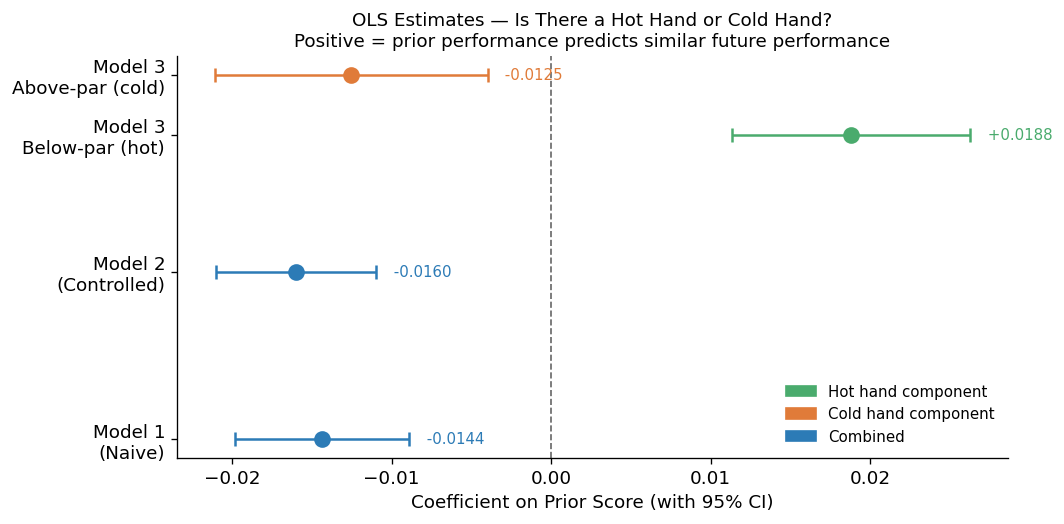

In [17]:

fig, ax = plt.subplots(figsize=(9, 4.5))

model_labels = ["Model 1\n(Naive)", "Model 2\n(Controlled)", "Model 3\n(Arkes Split)"]

plot_data = [
    # (label, coef, ci_low, ci_high, model_x, offset)
    ("prev_score", m1.params["prev_score_to_par"],
     m1.conf_int().loc["prev_score_to_par", 0],
     m1.conf_int().loc["prev_score_to_par", 1], 0, 0),
    ("prev_score", m2.params["prev_score_to_par"],
     m2.conf_int().loc["prev_score_to_par", 0],
     m2.conf_int().loc["prev_score_to_par", 1], 1, 0),
    ("below_par (hot hand)", m3.params["below_par_prev"],
     m3.conf_int().loc["below_par_prev", 0],
     m3.conf_int().loc["below_par_prev", 1], 2, -0.18),
    ("above_par (cold hand)", m3.params["above_par_prev"],
     m3.conf_int().loc["above_par_prev", 0],
     m3.conf_int().loc["above_par_prev", 1], 2, +0.18),
]

for label, coef, lo, hi, mx, offset in plot_data:
    y = mx + offset
    color = COLORS["birdie"] if "below" in label else (
            COLORS["bogey"]  if "above" in label else COLORS["blue"])
    ax.errorbar(coef, y, xerr=[[coef - lo], [hi - coef]],
                fmt="o", color=color, ms=9, capsize=4, capthick=1.5,
                elinewidth=1.5, lw=0)
    ax.text(hi + 0.0008, y, f" {coef:+.4f}", va="center", fontsize=9, color=color)

ax.axvline(0, color="black", lw=1.0, ls="--", alpha=0.6)
ax.set_yticks([0, 1, 2 - 0.18, 2 + 0.18])
ax.set_yticklabels(["Model 1\n(Naive)", "Model 2\n(Controlled)",
                    "Model 3\nBelow-par (hot)", "Model 3\nAbove-par (cold)"])
ax.set_xlabel("Coefficient on Prior Score (with 95% CI)")
ax.set_title("OLS Estimates — Is There a Hot Hand or Cold Hand?\n"
             "Positive = prior performance predicts similar future performance", fontsize=11)

green_p = mpatches.Patch(color=COLORS["birdie"], label="Hot hand component")
red_p   = mpatches.Patch(color=COLORS["bogey"],  label="Cold hand component")
blue_p  = mpatches.Patch(color=COLORS["blue"],   label="Combined")
ax.legend(handles=[green_p, red_p, blue_p], frameon=False, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("figures/04_ols_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
print("MODEL 3 INTERPRETATION")
print("=" * 55)

coef_below = m3.params["below_par_prev"]
pval_below = m3.pvalues["below_par_prev"]
coef_above = m3.params["above_par_prev"]
pval_above = m3.pvalues["above_par_prev"]

print(f"\nHot hand (below_par_prev):")
print(f"  Coefficient: {coef_below:+.4f}")
print(f"  p-value:     {pval_below:.4f}")
sig_below = pval_below < 0.05
print(f"  Significant (p<0.05)? {'YES' if sig_below else 'NO'}")
if sig_below:
    print(f"  -> A 1-stroke better-than-par hole predicts")
    print(f"     {coef_below:.4f} stroke improvement on the next hole")
else:
    print(f"  -> No statistically significant hot hand detected")

print(f"\nCold hand (above_par_prev):")
print(f"  Coefficient: {coef_above:+.4f}")
print(f"  p-value:     {pval_above:.4f}")
sig_above = pval_above < 0.05
print(f"  Significant (p<0.05)? {'YES' if sig_above else 'NO'}")
if sig_above:
    print(f"  -> A 1-stroke worse-than-par hole predicts")
    print(f"     {coef_above:.4f} stroke worse performance on the next hole")
    print(f"  -> Consistent with Arkes (2016): cold hand but no hot hand")
else:
    print(f"  -> No statistically significant cold hand detected")

print(f"\nFor comparison, Arkes (2016) found:")
print(f"  below_par_prev: ~0.007 (not significant)")
print(f"  above_par_prev: ~0.016–0.051 (all p<0.001, varies by hole window)")

MODEL 3 INTERPRETATION

Hot hand (below_par_prev):
  Coefficient: +0.0188
  p-value:     0.0000
  Significant (p<0.05)? YES
  -> A 1-stroke better-than-par hole predicts
     0.0188 stroke improvement on the next hole

Cold hand (above_par_prev):
  Coefficient: -0.0125
  p-value:     0.0041
  Significant (p<0.05)? YES
  -> A 1-stroke worse-than-par hole predicts
     -0.0125 stroke worse performance on the next hole
  -> Consistent with Arkes (2016): cold hand but no hot hand

For comparison, Arkes (2016) found:
  below_par_prev: ~0.007 (not significant)
  above_par_prev: ~0.016–0.051 (all p<0.001, varies by hole window)


## 5. Logistic Regression — Birdie and Bogey Probabilities

OLS treats the outcome as continuous, which works fine but doesn't answer the intuitive question: *does a birdie lead to another birdie?*

We run four logistic regressions:
- **Birdie → Birdie**: after a birdie, is the next hole more likely to be a birdie?
- **Bogey → Bogey**: after a bogey, is the next hole more likely to be a bogey?
- **Birdie → Bogey**: does a good hole protect you from a bad one?
- **Bogey → Birdie**: does a bad hole make you more (or less) likely to recover?


In [19]:
df_reg["made_birdie"] = (df_reg["score_to_par"] < 0).astype(int)
df_reg["made_bogey"]  = (df_reg["score_to_par"] > 0).astype(int)
df_reg["prev_birdie"] = (df_reg["prev_score_to_par"] < 0).astype(int)
df_reg["prev_bogey"]  = (df_reg["prev_score_to_par"] > 0).astype(int)

controls = df_reg[["hole_avg", "player_avg"]]

def run_logit(y, main_x):
    X = sm.add_constant(pd.concat([df_reg[[main_x]], controls], axis=1))
    return sm.Logit(y, X).fit(disp=False)

log_bb = run_logit(df_reg["made_birdie"], "prev_birdie")  # birdie -> birdie
log_dd = run_logit(df_reg["made_bogey"],  "prev_bogey")   # bogey  -> bogey
log_bd = run_logit(df_reg["made_bogey"],  "prev_birdie")  # birdie -> bogey
log_db = run_logit(df_reg["made_birdie"], "prev_bogey")   # bogey  -> birdie

models = {
    "After Birdie → Birdie":  (log_bb, "prev_birdie"),
    "After Bogey  → Bogey":   (log_dd, "prev_bogey"),
    "After Birdie → Bogey":   (log_bd, "prev_birdie"),
    "After Bogey  → Birdie":  (log_db, "prev_bogey"),
}

print(f"{'Model':35s}  {'Coef':>8s}  {'Odds Ratio':>12s}  {'p-value':>10s}  {'Sig':>5s}")
print("-" * 80)
for label, (model, var) in models.items():
    coef = model.params[var]
    OR   = np.exp(coef)
    pval = model.pvalues[var]
    sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"{label:35s}  {coef:+8.4f}  {OR:12.4f}  {pval:10.4f}  {sig:>5s}")

print()
print("Odds ratio > 1 = prior event increases probability of outcome")
print("Odds ratio < 1 = prior event decreases probability of outcome")

Model                                    Coef    Odds Ratio     p-value    Sig
--------------------------------------------------------------------------------
After Birdie → Birdie                 -0.1084        0.8973      0.0000    ***
After Bogey  → Bogey                  +0.0072        1.0072      0.7595       
After Birdie → Bogey                  +0.0285        1.0289      0.1390       
After Bogey  → Birdie                 +0.1274        1.1359      0.0000    ***

Odds ratio > 1 = prior event increases probability of outcome
Odds ratio < 1 = prior event decreases probability of outcome


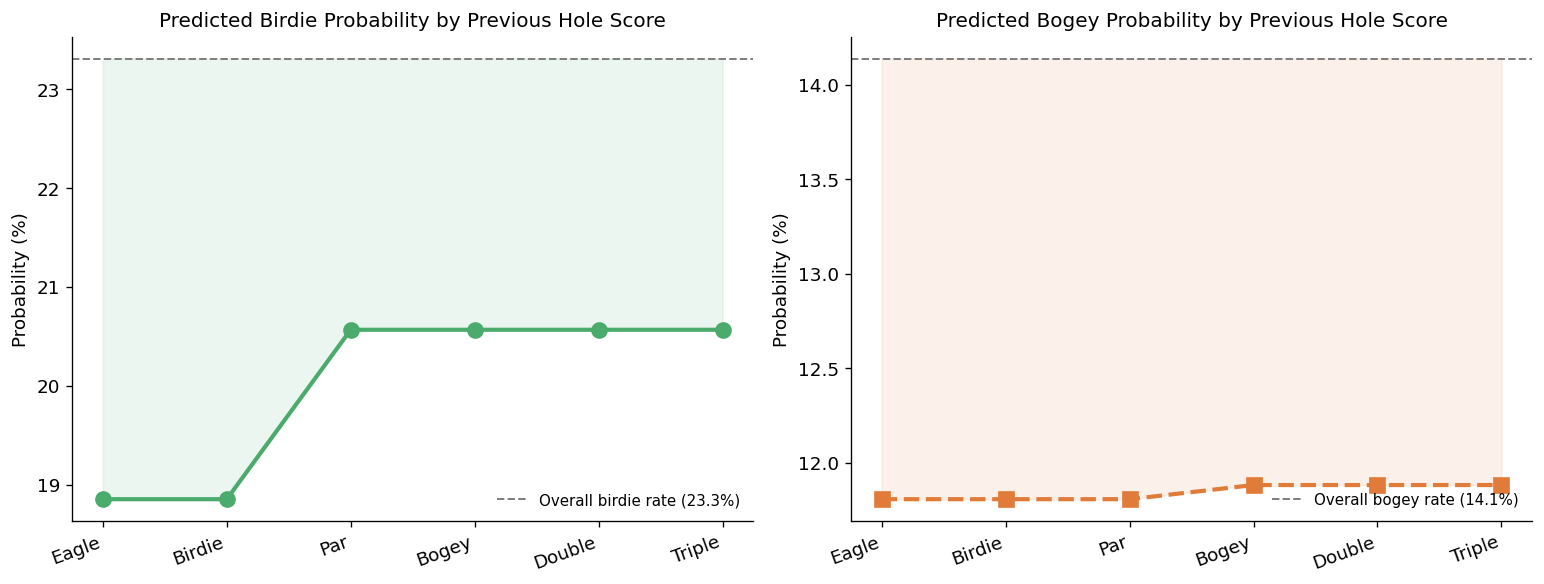

In [22]:

base_player = df_reg["player_avg"].mean()
base_diff   = df_reg["hole_avg"].mean()

prev_stp_range = np.arange(-2, 4)  # eagle to triple bogey
prev_labels    = ["Eagle", "Birdie", "Par", "Bogey", "Double", "Triple"]

birdie_probs = []
bogey_probs  = []

for stp in prev_stp_range:
    row = pd.DataFrame({
        "const":      [1.0],
        "prev_birdie": [1 if stp < 0 else 0],
        "prev_bogey":  [1 if stp > 0 else 0],
        "hole_avg":    [base_diff],
        "player_avg":  [base_player],
    })
    birdie_probs.append(log_bb.predict(row[["const", "prev_birdie", "hole_avg", "player_avg"]])[0])
    bogey_probs.append( log_dd.predict(row[["const", "prev_bogey",  "hole_avg", "player_avg"]])[0])

overall_birdie_rate = df_reg["made_birdie"].mean()
overall_bogey_rate  = df_reg["made_bogey"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(prev_stp_range, [p * 100 for p in birdie_probs],
             "o-", color=COLORS["birdie"], lw=2.5, ms=9)
axes[0].axhline(overall_birdie_rate * 100, color="gray", ls="--", lw=1.2,
                label=f"Overall birdie rate ({overall_birdie_rate:.1%})")
axes[0].fill_between(prev_stp_range, overall_birdie_rate * 100,
                     [p * 100 for p in birdie_probs], alpha=0.1, color=COLORS["birdie"])
axes[0].set_xticks(prev_stp_range)
axes[0].set_xticklabels(prev_labels, rotation=20, ha="right")
axes[0].set_title("Predicted Birdie Probability by Previous Hole Score", fontsize=12)
axes[0].set_ylabel("Probability (%)")
axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(prev_stp_range, [p * 100 for p in bogey_probs],
             "s--", color=COLORS["bogey"], lw=2.5, ms=9)
axes[1].axhline(overall_bogey_rate * 100, color="gray", ls="--", lw=1.2,
                label=f"Overall bogey rate ({overall_bogey_rate:.1%})")
axes[1].fill_between(prev_stp_range, overall_bogey_rate * 100,
                     [p * 100 for p in bogey_probs], alpha=0.1, color=COLORS["bogey"])
axes[1].set_xticks(prev_stp_range)
axes[1].set_xticklabels(prev_labels, rotation=20, ha="right")
axes[1].set_title("Predicted Bogey Probability by Previous Hole Score", fontsize=12)
axes[1].set_ylabel("Probability (%)")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("figures/05_logistic_predicted_probs.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Player Streakiness Rankings

Everything above estimates an *average* across all players. But golfers are individuals. Some might genuinely play in streaks while others revert to the mean quickly.

We measure **streakiness** as each player's average within-round lag-1 autocorrelation — how much their score on hole *n* correlates with their score on hole *n-1*, computed separately for each round and then averaged.

Positive = streaky (good holes cluster with good holes)  
Negative = mean-reverting (tends to bounce back after bad holes)


In [23]:
def player_round_autocorr(group):
    """Lag-1 autocorrelation of score_to_par within a single round.
    Returns NaN if too few holes or no variance."""
    s = group["score_to_par"].values
    if len(s) < 9 or np.std(s) == 0:
        return np.nan
    return pd.Series(s).autocorr(lag=1)


# Compute per player-tournament-round, then average up to player level
round_groups = holes_df.groupby(["player_id", "player_name", "tournament_id", "round"])
round_autocorr = round_groups.apply(player_round_autocorr).reset_index()
round_autocorr.columns = ["player_id", "player_name", "tournament_id", "round", "autocorr"]
round_autocorr = round_autocorr.dropna(subset=["autocorr"])

player_streakiness = (
    round_autocorr
    .groupby(["player_id", "player_name"])
    .agg(
        streakiness = ("autocorr", "mean"),
        n_rounds    = ("autocorr", "count"),
        se          = ("autocorr", "sem"),
    )
    .reset_index()
    .query("n_rounds >= 8")  # enough rounds for a meaningful average
    .sort_values("streakiness", ascending=False)
    .reset_index(drop=True)
)

print(f"Players with ≥8 qualifying rounds: {len(player_streakiness)}")
print()
print(f"Distribution of streakiness scores:")
print(player_streakiness["streakiness"].describe().round(5).to_string())
print()
print(f"Positive (streaky):       {(player_streakiness['streakiness'] > 0).sum()} players")
print(f"Negative (mean-reverting): {(player_streakiness['streakiness'] < 0).sum()} players")

Players with ≥8 qualifying rounds: 190

Distribution of streakiness scores:
count    190.00000
mean      -0.07735
std        0.04962
min       -0.26468
25%       -0.10142
50%       -0.07766
75%       -0.04930
max        0.04926

Positive (streaky):       10 players
Negative (mean-reverting): 180 players


In [24]:
# One-sample t-test: is the average streakiness score different from zero?
t_stat, p_val = stats.ttest_1samp(player_streakiness["streakiness"], popmean=0)
mean_s = player_streakiness["streakiness"].mean()

print("One-sample t-test: Is mean streakiness = 0 across players?")
print(f"  Mean streakiness: {mean_s:.6f}")
print(f"  T-statistic:      {t_stat:.4f}")
print(f"  P-value:          {p_val:.4f}")
print()
if p_val < 0.05:
    direction = "positive (streaky)" if mean_s > 0 else "negative (mean-reverting)"
    print(f"  -> Significant. Players on average show {direction} autocorrelation.")
else:
    print(f"  -> Not significant. Can't distinguish from zero on average.")

One-sample t-test: Is mean streakiness = 0 across players?
  Mean streakiness: -0.077349
  T-statistic:      -21.4888
  P-value:          0.0000

  -> Significant. Players on average show negative (mean-reverting) autocorrelation.


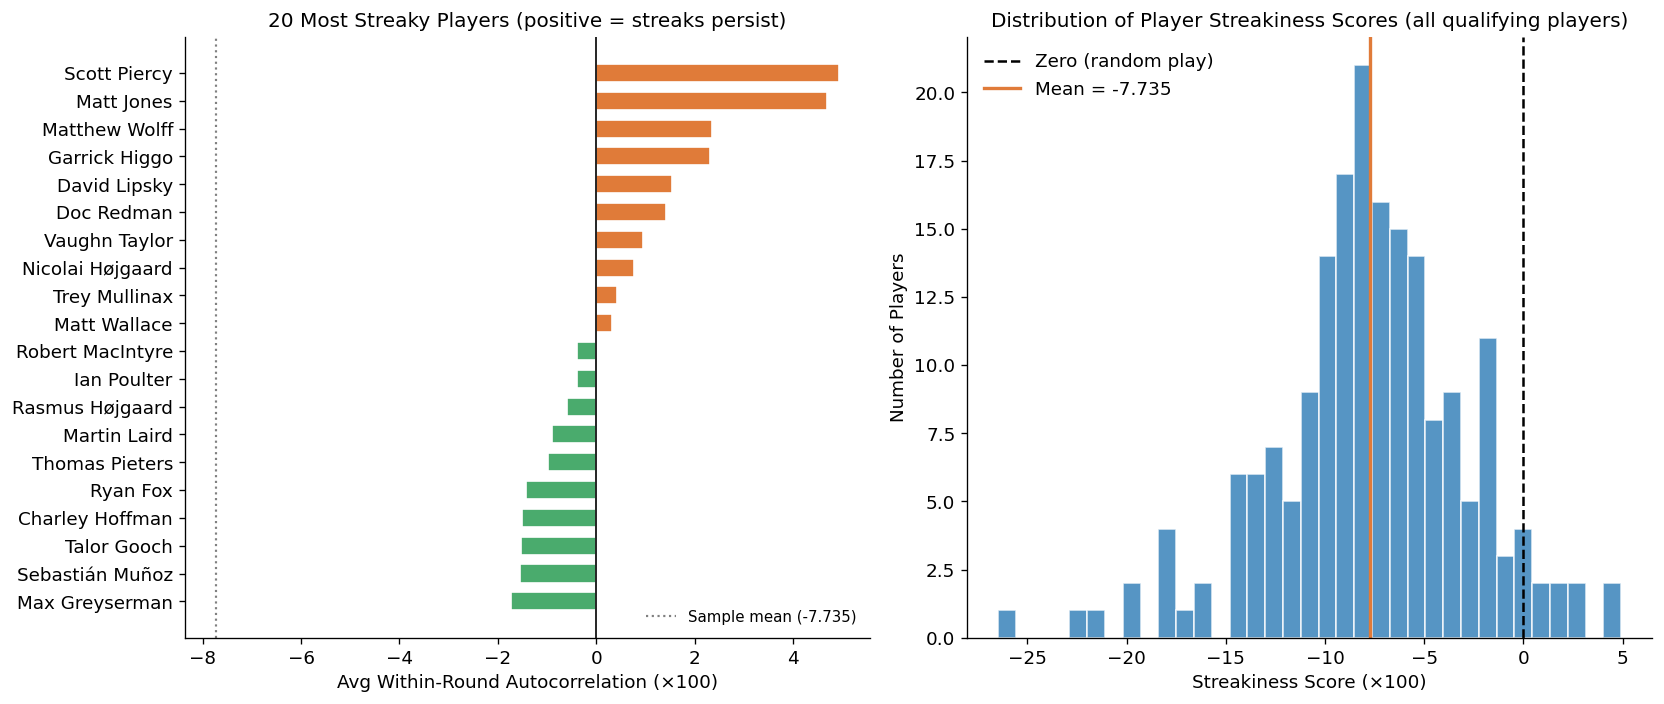

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Top 20 streakiest players
top20 = player_streakiness.head(20).copy()
clrs  = [COLORS["bogey"] if v > 0 else COLORS["birdie"] for v in top20["streakiness"]]

axes[0].barh(
    top20["player_name"], top20["streakiness"] * 100,
    color=clrs, height=0.65, edgecolor="white"
)
axes[0].axvline(0, color="black", lw=1.0)
axes[0].axvline(mean_s * 100, color="gray", ls=":", lw=1.3,
                label=f"Sample mean ({mean_s*100:.3f})")
axes[0].set_title("20 Most Streaky Players (positive = streaks persist)", fontsize=12)
axes[0].set_xlabel("Avg Within-Round Autocorrelation (×100)")
axes[0].invert_yaxis()
axes[0].legend(frameon=False, fontsize=9)

# Right: Full distribution with zero marked
axes[1].hist(
    player_streakiness["streakiness"] * 100,
    bins=35, color=COLORS["blue"], edgecolor="white", alpha=0.8
)
axes[1].axvline(0, color="black", ls="--", lw=1.5, label="Zero (random play)")
axes[1].axvline(mean_s * 100, color=COLORS["bogey"], lw=2.0,
                label=f"Mean = {mean_s*100:.3f}")
axes[1].set_title("Distribution of Player Streakiness Scores (all qualifying players)", fontsize=12)
axes[1].set_xlabel("Streakiness Score (×100)")
axes[1].set_ylabel("Number of Players")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/06_player_streakiness.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# Bottom 15 (most mean-reverting) and top 15 (most streaky)
print("15 most STREAKY players (positive autocorrelation):")
print("-" * 52)
print(player_streakiness[["player_name", "streakiness", "n_rounds"]]
      .head(15)
      .rename(columns={"streakiness": "score", "n_rounds": "rounds"})
      .to_string(index=False))

print()
print("15 most MEAN-REVERTING players (negative autocorrelation):")
print("-" * 52)
print(player_streakiness[["player_name", "streakiness", "n_rounds"]]
      .tail(15)
      .sort_values("streakiness")
      .rename(columns={"streakiness": "score", "n_rounds": "rounds"})
      .to_string(index=False))

15 most STREAKY players (positive autocorrelation):
----------------------------------------------------
     player_name     score  rounds
    Scott Piercy  0.049259       8
      Matt Jones  0.046952      12
   Matthew Wolff  0.023516      24
   Garrick Higgo  0.023079       8
    David Lipsky  0.015337       8
      Doc Redman  0.014182      16
   Vaughn Taylor  0.009499       8
Nicolai Højgaard  0.007675       8
   Trey Mullinax  0.004107      12
    Matt Wallace  0.003122      16
Robert MacIntyre -0.003984      44
     Ian Poulter -0.004010      28
 Rasmus Højgaard -0.005909       8
    Martin Laird -0.008967       8
  Thomas Pieters -0.009863       8

15 most MEAN-REVERTING players (negative autocorrelation):
----------------------------------------------------
       player_name     score  rounds
  Romain Langasque -0.264681       8
Francesco Molinari -0.221899      16
      Xinjun Zhang -0.218517       8
       Ryan Armour -0.200436       8
        Brandon Wu -0.196439       8


## 7. Does Streakiness Predict Tournament Performance?

If streakiness is meaningful — rather than just statistical noise — it might tell us something about a player's likely performance. We test this by merging each player's streakiness score with their average tournament score-to-par and running a simple OLS regression.

Note: a significant result here doesn't prove streakiness *causes* better or worse performance. It would just mean the two tend to go together.

In [30]:
# Build performance metric from leaderboard data
lb = leaderboards.copy()
lb["score_numeric"] = pd.to_numeric(lb["score_to_par"], errors="coerce")

player_perf = (
    lb
    .groupby("player_id")
    .agg(
        avg_score_to_par = ("score_numeric",  "mean"),
        n_tournaments    = ("tournament_id", "nunique"),
    )
    .reset_index()
    .query("n_tournaments >= 5")
)

analysis = (
    player_streakiness
    .merge(player_perf, on="player_id", how="inner")
    .dropna(subset=["avg_score_to_par", "streakiness"])
)

print(f"Players in performance analysis: {len(analysis)}")
print(f"Mean avg score to par: {analysis['avg_score_to_par'].mean():.3f}")
print()

X_p = sm.add_constant(analysis["streakiness"])
m_perf = sm.OLS(analysis["avg_score_to_par"], X_p).fit(cov_type="HC3")

print("Regression: avg_score_to_par ~ streakiness")
print(f"  Intercept:    {m_perf.params['const']:+.4f}")
print(f"  Coefficient:  {m_perf.params['streakiness']:+.4f}")
print(f"  p-value:      {m_perf.pvalues['streakiness']:.4f}")
print(f"  R²:           {m_perf.rsquared:.5f}")
print()
if m_perf.pvalues["streakiness"] < 0.05:
    direction = "worse" if m_perf.params["streakiness"] > 0 else "better"
    print(f"  -> Significant: streakier players tend to perform {direction} in tournaments")
else:
    print(f"  -> Not significant: streakiness does not predict tournament performance")

Players in performance analysis: 190
Mean avg score to par: -2.545

Regression: avg_score_to_par ~ streakiness
  Intercept:    -2.6347
  Coefficient:  -1.1556
  p-value:      0.7273
  R²:           0.00071

  -> Not significant: streakiness does not predict tournament performance


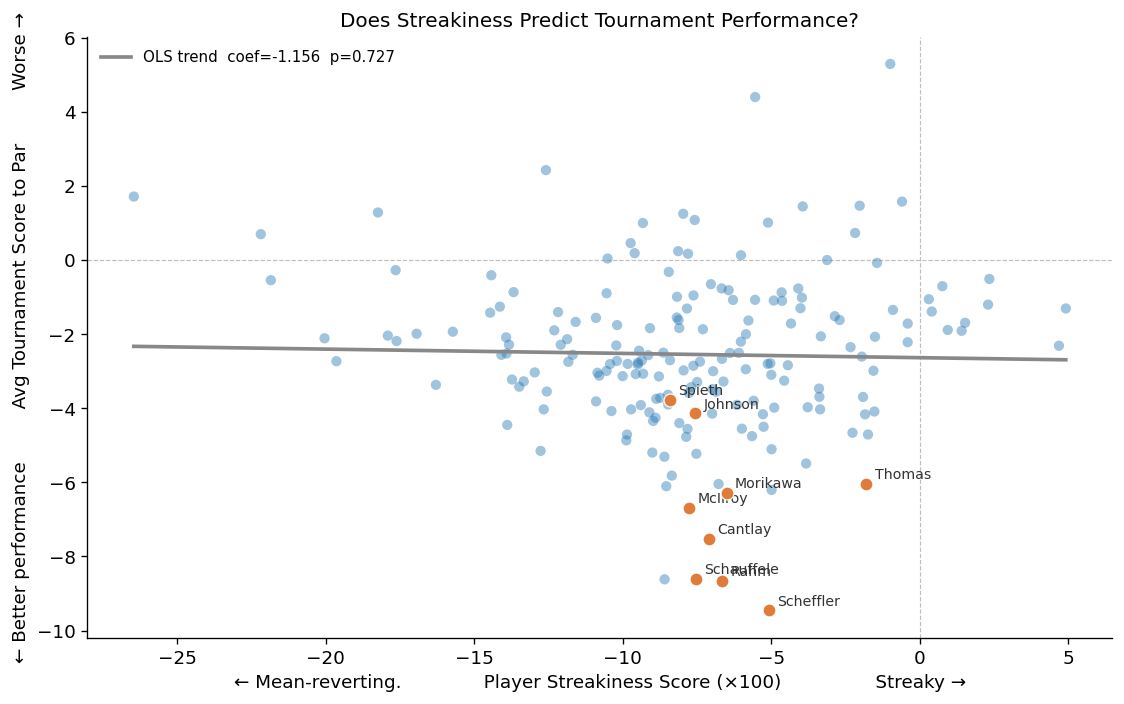

In [34]:
NOTABLE = [
    "Rory McIlroy", "Scottie Scheffler", "Jon Rahm", "Tiger Woods",
    "Xander Schauffele", "Collin Morikawa", "Jordan Spieth",
    "Justin Thomas", "Dustin Johnson", "Patrick Cantlay",
]

fig, ax = plt.subplots(figsize=(9.5, 6))

ax.scatter(
    analysis["streakiness"] * 100,
    analysis["avg_score_to_par"],
    alpha=0.45, s=38, color=COLORS["blue"], edgecolors="none", zorder=2
)

x_line = np.linspace(analysis["streakiness"].min(), analysis["streakiness"].max(), 200)
y_line = m_perf.params["const"] + m_perf.params["streakiness"] * x_line
sig    = m_perf.pvalues["streakiness"] < 0.05
ax.plot(
    x_line * 100, y_line,
    lw=2.2, color=COLORS["bogey"] if sig else COLORS["neutral"],
    label=f"OLS trend  coef={m_perf.params['streakiness']:.3f}  p={m_perf.pvalues['streakiness']:.3f}",
    zorder=3
)

for _, row in analysis.iterrows():
    if row["player_name"] in NOTABLE:
        ax.scatter(row["streakiness"] * 100, row["avg_score_to_par"],
                   color=COLORS["bogey"], s=60, zorder=4, edgecolors="white", lw=0.7)
        ax.annotate(
            row["player_name"].split()[-1],
            xy=(row["streakiness"] * 100, row["avg_score_to_par"]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=8.5, color="#333"
        )

ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.5)
ax.axvline(0, color="gray", lw=0.7, ls="--", alpha=0.5)
ax.set_xlabel("← Mean-reverting.              Player Streakiness Score (×100)                Streaky →")
ax.set_ylabel("← Better performance         Avg Tournament Score to Par         Worse →")
ax.set_title("Does Streakiness Predict Tournament Performance?", fontsize=12)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("figures/07_streakiness_vs_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary of Findings

In [35]:
print("=" * 65)
print("SUMMARY: HOT HAND STUDY — 2020–2024 PGA TOUR DATA")
print("=" * 65)

print(f"\nDataset: {len(holes_df):,} consecutive hole pairs across")
print(f"         {holes_df['tournament_name'].nunique()} tournaments, "
      f"{holes_df['player_id'].nunique()} players")

print("\n── OLS Regression (Model 3 — Arkes Split) ────────────────")
coef_hot  = m3.params["below_par_prev"]
pval_hot  = m3.pvalues["below_par_prev"]
coef_cold = m3.params["above_par_prev"]
pval_cold = m3.pvalues["above_par_prev"]

hot_verdict  = "SIGNIFICANT" if pval_hot  < 0.05 else "NOT significant"
cold_verdict = "SIGNIFICANT" if pval_cold < 0.05 else "NOT significant"

print(f"  Hot hand (below_par_prev):  coef={coef_hot:+.4f}  p={pval_hot:.4f}  [{hot_verdict}]")
print(f"  Cold hand (above_par_prev): coef={coef_cold:+.4f}  p={pval_cold:.4f}  [{cold_verdict}]")

print("\n── Logistic Regression ─────────────────────────────────────")
for label, (model, var) in models.items():
    coef = model.params[var]
    OR   = np.exp(coef)
    pval = model.pvalues[var]
    verdict = "sig" if pval < 0.05 else "n.s."
    print(f"  {label:35s}  OR={OR:.3f}  p={pval:.4f}  [{verdict}]")

print("\n── Player Streakiness ───────────────────────────────────────")
print(f"  Mean streakiness score: {mean_s:.5f}")
print(f"  T-test p-value:         {p_val:.4f}  "
      f"[{'sig' if p_val < 0.05 else 'n.s.'}]")
top_player = player_streakiness.iloc[0]
print(f"  Most streaky player:    {top_player['player_name']} "
      f"(score={top_player['streakiness']:.4f}, n={top_player['n_rounds']})")

print("\n── Streakiness → Performance ───────────────────────────────")
print(f"  Coefficient: {m_perf.params['streakiness']:+.4f}  "
      f"p={m_perf.pvalues['streakiness']:.4f}  "
      f"[{'sig' if m_perf.pvalues['streakiness'] < 0.05 else 'n.s.'}]")

print("\n── vs. Arkes (2016) ─────────────────────────────────────────")
print("  Arkes found:  hot hand NOT significant, cold hand SIGNIFICANT")
print(f"  This study:   hot hand {'  ' if pval_hot < 0.05 else 'NOT '}significant, "
      f"cold hand {'  ' if pval_cold < 0.05 else 'NOT '}significant")
print("  (differences may reflect: smaller sample, different era,")
print("   ESPN vs ShotLink data, top-30 vs top-200 selection)")

SUMMARY: HOT HAND STUDY — 2020–2024 PGA TOUR DATA

Dataset: 130,499 consecutive hole pairs across
         22 tournaments, 246 players

── OLS Regression (Model 3 — Arkes Split) ────────────────
  Hot hand (below_par_prev):  coef=+0.0188  p=0.0000  [SIGNIFICANT]
  Cold hand (above_par_prev): coef=-0.0125  p=0.0041  [SIGNIFICANT]

── Logistic Regression ─────────────────────────────────────
  After Birdie → Birdie                OR=0.897  p=0.0000  [sig]
  After Bogey  → Bogey                 OR=1.007  p=0.7595  [n.s.]
  After Birdie → Bogey                 OR=1.029  p=0.1390  [n.s.]
  After Bogey  → Birdie                OR=1.136  p=0.0000  [sig]

── Player Streakiness ───────────────────────────────────────
  Mean streakiness score: -0.07735
  T-test p-value:         0.0000  [sig]
  Most streaky player:    Scott Piercy (score=0.0493, n=8)

── Streakiness → Performance ───────────────────────────────
  Coefficient: -1.1556  p=0.7273  [n.s.]

── vs. Arkes (2016) ────────────────────────